In [1]:
%load_ext autoreload
%autoreload 2
import time
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from estimation_fct import *
from graph_format import *

# Load model
from model import ModelClass

model = ModelClass() 

par = model.par
sol = model.sol
sim = model.sim


In [2]:
wealth = pd.read_csv("Data_cohort/wealth.csv").iloc[:, 1] # 34 - 75 
extensive = pd.read_csv("Data_cohort/extensive.csv").iloc[:, 1][:45-9] # 38 - 78
intensive = pd.read_csv("Data_cohort/intensive.csv").iloc[:, 1][:40-27] # 56 - 78

In [3]:
# means_string = "Data ny def/mean_matrix.csv"
# covariance_string = "Data ny def/variance_matrix.csv"

# variables = ["extensive_v2", "formue_plsats", "yearly_hours"]

# mean, variance_diag = load_and_process_data(means_string, covariance_string, par, variables)

mean = np.concatenate([extensive, wealth, intensive])

# Generate a variance matrix with the same length as the extended series but with the mean of the series
variance_cut = np.concatenate([np.full(len(extensive), np.nanmean(extensive)**2 / 2), 
                               np.full(len(wealth), np.nanmean(wealth)**2), 
                               np.full(len(intensive), np.nanmean(intensive)**2) / 2])



diag_inv = 1 / variance_cut
weight = np.diag(diag_inv)

In [ ]:
par.N_a = 2
par.N_k = 2
par.N_s = 2

par.simN = 50000

model.solve()
model.simulate()

result_list = []

for grid in range(2, 40):

    par.N_a = grid
    par.N_k = grid
    par.N_s = grid

    theta_init = np.array([1.3114765509, 2.2072921860, 17.7679642766, 0.4332884446, 0.0301527608, 6.9217248519])

    theta_names = ("sigma", "gamma", "mu", "zeta", "gamma_1", "gamma_2")

    orig_bounds = [(0.1, 6.0),   # sigma
               (0.1, 10.0),  # gamma
               (0.0, 20.0),  # mu
               (0.0, 15.0),  # zeta
               (0.0, 0.3),  # gamma_1
               (0.01, 10.0)   # gamma_2
               ] 
    
    theta_init_scaled = scale_params(theta_init, orig_bounds)

    objective = lambda theta: obj_func(theta, theta_names, mean, weight, model, orig_bounds, do_print=False, return_extra_info=True)

    result, time = objective(theta_init_scaled)

    print(f"Grid: {grid}, Result: {result}, Time: {time:.2f} seconds")

    result_list.append((grid, result, time))

Grid: 2, Result: 26.027863652593517, Time: 13.27 seconds
Grid: 3, Result: 20.362540506687168, Time: 15.02 seconds


In [ ]:
par

namespace(speed='FAST',
          start_age=30,
          T=70,
          beta=0.96,
          sigma=1.359950492,
          gamma=4.8328134193,
          mu=7.1157921694,
          a_bar=0.001,
          zeta=1.9470458933,
          gamma_1=0.0044065569,
          gamma_2=2.254131193,
          renten=0.0211947668,
          r_s=0.0179519674796,
          r_a=0.012292964744000002,
          w_0=136.83,
          k_0=11.588177,
          beta_1=0.024787,
          beta_2=-4.2e-05,
          delta=0.03,
          full_time_hours=1924.0,
          labor_market_rate=0.08,
          employment_deduction_rate=0.095,
          bottom_tax_rate=0.1213,
          top_tax_rate=0.15,
          municipal_tax_rate=0.2491,
          personal_allowance=54648,
          employment_deduction_cap=39564,
          top_tax_threshold=592553,
          retirement_age=35,
          first_retirement=30,
          last_retirement=55,
          early_benefits_lag=0,
          m=12.0,
          tau_private=array(

In [10]:
par.last_retirement

55

In [5]:
par.N_a = 45
par.N_k = 45
par.N_s = 45

In [ ]:
def randomize_theta_init(theta_init, bounds, pct=0.3):
    randomized = []
    for val, (lower, upper) in zip(theta_init, bounds):
        delta = pct * val
        min_val = max(lower, val - delta)
        max_val = min(upper, val + delta)
        randomized_val = np.random.uniform(min_val, max_val)
        randomized.append(randomized_val)
    return np.array(randomized)

# Prepare SMM
theta_names = ("sigma", "gamma", "mu", "zeta", "gamma_1", "gamma_2")

theta_init = np.array([1.3118721602, 2.0653721897, 17.4452456743, 0.4636828507, 0.0293249810, 7.6965893793, ])

# Original bounds
orig_bounds = [(0.1, 6.0),   # sigma
               (0.1, 10.0),  # gamma
               (0.0, 20.0),  # mu
               (0.0, 15.0),  # zeta
               (0.0, 0.3),  # gamma_1
               (0.01, 10.0)   # gamma_2
               ] 

theta_init_scaled = scale_params(theta_init, orig_bounds)

theta_random = randomize_theta_init(theta_init, orig_bounds)
theta_random_scaled = scale_params(theta_random, orig_bounds)

# Do SMM
objective = lambda theta: obj_func(theta, theta_names, mean, weight, model, orig_bounds, do_print=True)

res = minimize(
    objective, 
    theta_init_scaled,
    method='nelder-mead',
    bounds=[(0,1)] * len(theta_init_scaled),
    tol=1e-6,
    options={"maxiter":2000}
)

theta_final = unscale_params(res.x, orig_bounds)

print(theta_final)

1.3118721602, 2.0653721897, 17.4452456743, 0.4636828507, 0.0293249810, 7.6965893793, 
Error = 1.58456, x = [0.67955301 0.63965015], Time = 743.3 seconds
1.3724657682, 2.0653721897, 17.4452456743, 0.4636828507, 0.0293249810, 7.6965893793, 
Error = 24.48096, x = [0. 1.], Time = 655.6 seconds
1.3118721602, 2.1636407992, 17.4452456743, 0.4636828507, 0.0293249810, 7.6965893793, 
Error = 1.60753, x = [0.74976876 0.64321034], Time = 657.5 seconds
1.3118721602, 2.0653721897, 18.3175079580, 0.4636828507, 0.0293249810, 7.6965893793, 
Error = 1.63985, x = [0.69952623 0.60398832], Time = 653.7 seconds
1.3118721602, 2.0653721897, 17.4452456743, 0.4868669932, 0.0293249810, 7.6965893793, 


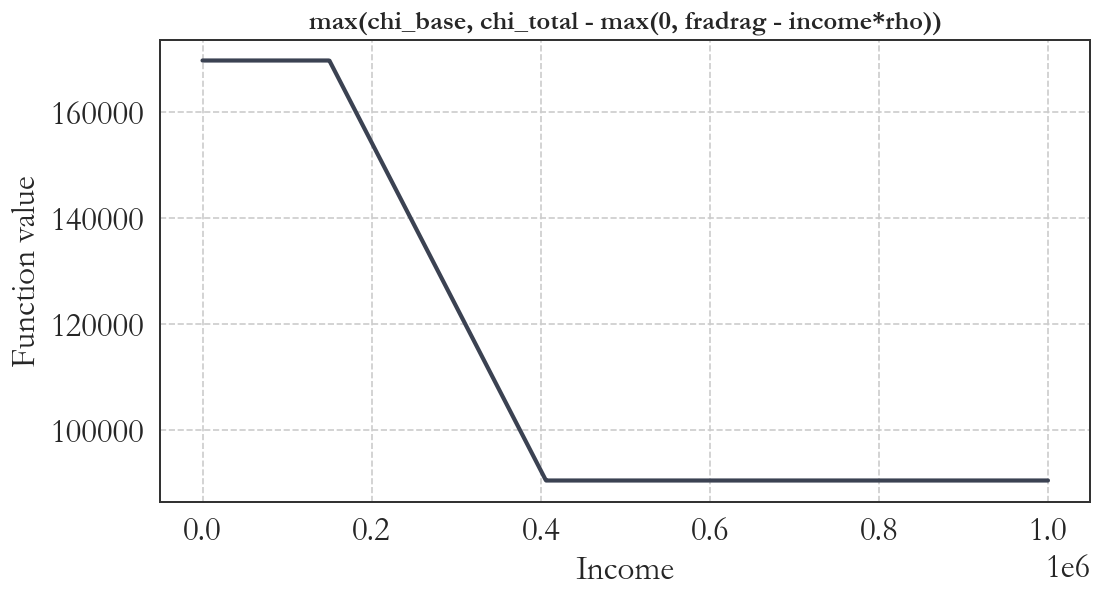

In [9]:
# Income grid
income = np.linspace(0, 1000000, 1000)

# Function definition
value = np.maximum(par.chi_base, par.chi_total - np.maximum(0, income - par.fradrag ) * par.rho )

# Plot (single plot, no specific colors)
plt.figure()
plt.plot(income, value)
plt.xlabel("Income")
plt.ylabel("Function value")
plt.title("max(chi_base, chi_total - max(0, fradrag - income*rho))")
plt.show()

In [6]:
res.x

array([0., 1.])

In [13]:
res.x

array([0.77824384, 0.81427222])

1 NVFI
1 Fixed
0 NVFI
0 Fixed
2.218784432307681


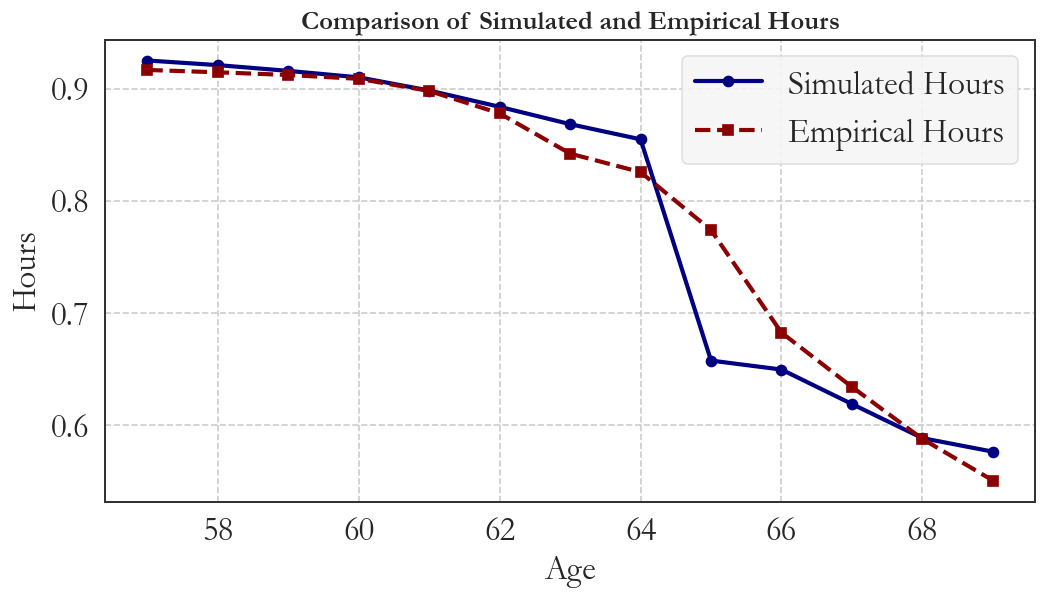

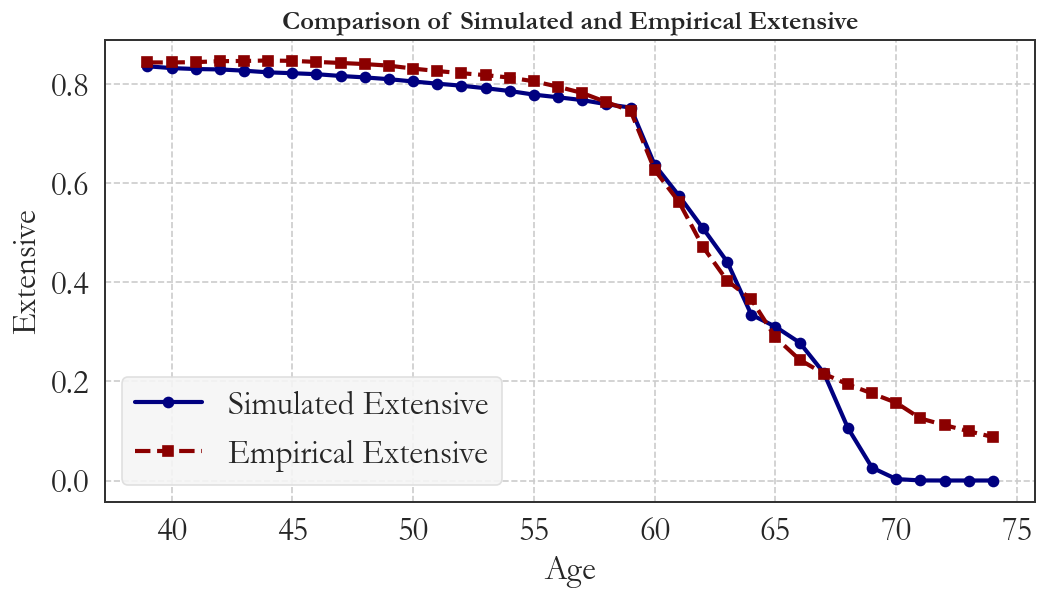

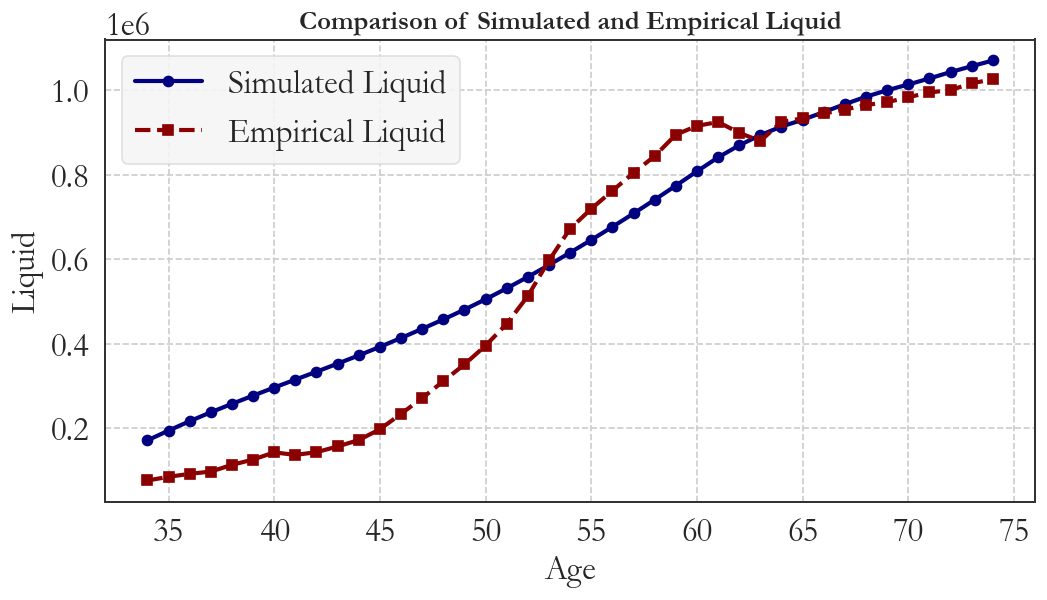

In [5]:
# Load the model with calibrated values
theta_names = ("sigma", "gamma", "mu", "zeta", "gamma_1", "gamma_2")
# # theta_names = ("beta", "zeta")

# theta_final = unscale_params(res.x, orig_bounds)

par.N_a = 10
par.N_k = 15
par.N_s = 10

theta_final = np.array([1.3150532915, 2.0265482775, 16.7184842436, 0.4003182315, 0.0272555094, 12.4674286295, ])
# theta_final = np.array([1.2404187284, 0.9828068645, 15.3240195017, 1.6162994089, 0.0228963446, 6.4808303616])

for i, name in enumerate(theta_names):
    setattr(model.par, name, theta_final[i])

efterloen_options = [1, 0]
flexible_hours_options = ["NVFI", "Fixed"]

sim_means = []

for efterloen in efterloen_options:
    for flexible_hours in flexible_hours_options:

        print(efterloen, flexible_hours)

        par.efter = efterloen
        par.flexible_hours = flexible_hours

        model.solve()
        model.simulate()

        sim_mean = [
            np.nan_to_num(np.nanmean(np.where(model.sim.ex == 1, model.sim.h, np.nan), axis=0)[:45], nan=0.0),
            np.mean(model.sim.ex, axis=0)[:45],
            np.mean(model.sim.a, axis=0),
            np.clip(np.mean(model.sim.s, axis=0), 0, None)
        ]

        sim_means.append(sim_mean)

def loss_fn(params):
    hours_mean, extensive_mean, liquid_mean, _ = calc_means(sim_means, params)

    mom_sim = np.concatenate([extensive_mean[9:45], liquid_mean[4:45], hours_mean[27:40]])

    mom_data = mean

    return (mom_data - mom_sim).T @ weight @ (mom_data - mom_sim)

def calc_means(sim_means, params):
    efterloen_share = params[0]
    flexible_share = params[1]

    p11 = efterloen_share * flexible_share
    p10 = efterloen_share * (1 - flexible_share)
    p01 = (1 - efterloen_share) * flexible_share
    p00 = (1 - efterloen_share) * (1 - flexible_share)

    hours_mean              = p11*sim_means[0][0] + p10*sim_means[1][0] + p01*sim_means[2][0] + p00*sim_means[3][0]
    extensive_mean          = p11*sim_means[0][1] + p10*sim_means[1][1] + p01*sim_means[2][1] + p00*sim_means[3][1]
    liquid_mean             = p11*sim_means[0][2] + p10*sim_means[1][2] + p01*sim_means[2][2] + p00*sim_means[3][2]
    illiquid_mean           = p11*sim_means[0][3] + p10*sim_means[1][3] + p01*sim_means[2][3] + p00*sim_means[3][3]

    return hours_mean, extensive_mean, liquid_mean, illiquid_mean

x0 = np.array([0.55, 0.2])
bounds = [(0.0, 1.0), (0.0, 1.0)]

res = minimize(loss_fn, x0, method='L-BFGS-B', bounds=bounds,
               options={'ftol':1e-12, 'gtol':1e-8, 'maxiter':200})

print(res.fun)

test_params = np.array([1, 1])

hours_mean, extensive_mean, liquid_mean, illiquid_mean = calc_means(sim_means, res.x)

# plot the graph with calibrated values 
a_dict = {
    'hours': [hours_mean[27:40], intensive, 27],
    'extensive': [extensive_mean[9:45], extensive, 9],
    # 'illiquid': [illiquid_mean, moments['savings']],
    'liquid': [liquid_mean[4:45], wealth, 4]
}



# Define colors
simulated_color = "navy"  # Dark blue
empirical_color = "darkred"  # Dark red
ci_color = "lightcoral"  # Light red for confidence bands

for key, (simulated, empirical, extra_age) in a_dict.items():
    plt.figure(figsize=(10, 5))
    
    x_vals = np.arange(len(empirical)) + par.start_age + extra_age
    
    plt.plot(x_vals, simulated, label=f"Simulated {key.capitalize()}", marker="o", color=simulated_color)
    plt.plot(x_vals, empirical, label=f"Empirical {key.capitalize()}", linestyle="--", marker="s", color=empirical_color)

    # # 99.9% confidence interval
    # ci = std_dev
    # plt.fill_between(x_vals, empirical - ci, empirical + ci, color=ci_color, alpha=0.4, label="Empirical Standard Deviation")

    plt.xlabel("Age")
    plt.ylabel(key.capitalize())
    plt.title(f"Comparison of Simulated and Empirical {key.capitalize()}")
    plt.legend()
    plt.grid(True)
    plt.show()



In [6]:
np.mean(model.sim.w[:, 0])

362117.9373998743

In [22]:
mean

array([8.435925e-01, 8.435154e-01, 8.441700e-01, 8.460949e-01,
       8.465352e-01, 8.474531e-01, 8.466660e-01, 8.445823e-01,
       8.424961e-01, 8.402238e-01, 8.371004e-01, 8.310839e-01,
       8.262355e-01, 8.218229e-01, 8.179540e-01, 8.129473e-01,
       8.055419e-01, 7.945270e-01, 7.818813e-01, 7.634845e-01,
       7.460568e-01, 6.265649e-01, 5.625422e-01, 4.713698e-01,
       4.032554e-01, 3.655361e-01, 2.887719e-01, 2.437364e-01,
       2.155998e-01, 1.937971e-01, 1.756895e-01, 1.568694e-01,
       1.252647e-01, 1.117349e-01, 9.944560e-02, 8.779060e-02,
       7.660272e+04, 8.534753e+04, 9.238104e+04, 9.773721e+04,
       1.136008e+05, 1.262642e+05, 1.430931e+05, 1.371962e+05,
       1.435896e+05, 1.571659e+05, 1.723727e+05, 1.979094e+05,
       2.343801e+05, 2.715664e+05, 3.115755e+05, 3.512812e+05,
       3.958962e+05, 4.473266e+05, 5.132705e+05, 5.974079e+05,
       6.725340e+05, 7.195581e+05, 7.623489e+05, 8.045761e+05,
       8.443857e+05, 8.950083e+05, 9.158208e+05, 9.2500

In [21]:
sim.c

array([[184866.13088578, 186602.1383425 , 191743.74430908, ...,
        186594.32736013, 185120.242776  , 173605.6960125 ],
       [276897.66969357, 289874.08785659, 298310.83578186, ...,
        157285.7590384 , 157716.16496889, 145923.16422746],
       [350730.16390204, 333651.76349848, 328074.34409066, ...,
        225817.68302452, 225767.952141  , 213813.40258799],
       ...,
       [ 88806.02035934,  88855.06374531,  88871.66622059, ...,
        117738.57874625, 116842.25128444, 105535.75347164],
       [165449.26085836, 169822.28229832, 175213.74056011, ...,
        184438.04641276, 182829.68037697, 169183.45447476],
       [ 88879.62910341,  88925.91271034,  88939.86391291, ...,
        117738.51421846, 116842.14322288, 105535.68820261]])

In [26]:
sim.c

array([[184866.13088578, 186602.1383425 , 191743.74430908, ...,
        186594.32736013, 185120.242776  , 173605.6960125 ],
       [276897.66969357, 289874.08785659, 298310.83578186, ...,
        157285.7590384 , 157716.16496889, 145923.16422746],
       [350730.16390204, 333651.76349848, 328074.34409066, ...,
        225817.68302452, 225767.952141  , 213813.40258799],
       ...,
       [ 88806.02035934,  88855.06374531,  88871.66622059, ...,
        117738.57874625, 116842.25128444, 105535.75347164],
       [165449.26085836, 169822.28229832, 175213.74056011, ...,
        184438.04641276, 182829.68037697, 169183.45447476],
       [ 88879.62910341,  88925.91271034,  88939.86391291, ...,
        117738.51421846, 116842.14322288, 105535.68820261]])

In [30]:
(186602.1383425 - 184866.13088578) / 184866.13088578

0.009390619300582367

In [ ]:
 186602.1383425 

In [40]:
mean_dev

array([ 2.41101008e+00,  2.14812681e+00,  1.84474986e+00,  1.52397482e+00,
        1.52923233e+00,  1.29387017e+00,  1.15727275e+00,  1.08824843e+00,
        9.18446040e-01,  8.15104029e-01,  7.59301561e-01,  5.85601122e-01,
        5.70491916e-01,  3.78765933e-01,  2.78118960e-01,  1.43049843e-01,
       -5.09334723e-02, -1.09483973e-01, -2.30843944e-01, -2.84146183e-01,
       -3.22376743e-01, -3.13169696e-01, -3.30505517e-01, -3.29981659e-01,
       -3.55897563e-01, -2.71953277e-01, -2.01336193e-01, -2.23373019e-01,
       -1.10038968e-01, -1.94527179e+00, -2.44664817e-01, -2.29352666e-01,
       -8.60597897e-02,  3.38962925e-01,  1.41599180e+01, -7.42987235e-02,
        1.87649640e-01, -4.02092581e-01, -8.74403733e-01, -4.74123529e-01,
       -5.49239353e-01, -4.62224208e-01, -3.17829101e-01, -2.20667446e-01,
       -3.80914528e-01, -4.90422972e-01, -4.78685135e-01, -4.40701023e-01,
       -4.91591731e-01, -1.57069034e+00, -1.36663512e+00,  7.65788644e-03,
        9.69860668e-02,  

In [44]:
upper

array([ 2.52704544e+00,  2.24650408e+00,  1.93237578e+00,  1.60444071e+00,
        1.60452956e+00,  1.36280736e+00,  1.22291512e+00,  1.15095257e+00,
        9.78675261e-01,  8.73679540e-01,  8.17819145e-01,  6.42891312e-01,
        6.27101131e-01,  4.35067280e-01,  3.33826793e-01,  1.97575672e-01,
        2.70820878e-03, -5.51666314e-02, -1.77708517e-01, -2.30895991e-01,
       -2.70031593e-01, -2.62116001e-01, -2.80136945e-01, -2.79764949e-01,
       -3.06267158e-01, -2.22263745e-01, -1.52869354e-01, -1.75596506e-01,
       -6.28128926e-02, -1.87202999e+00, -1.87910696e-01, -1.77704432e-01,
       -4.00619733e-02,  3.80065388e-01,  1.42691938e+01, -5.96235625e-02,
        2.01975376e-01, -3.86630991e-01, -8.64739113e-01, -4.67178598e-01,
       -5.42035907e-01, -4.53900459e-01, -3.09627793e-01, -2.10789883e-01,
       -3.69267139e-01, -4.77484947e-01, -4.63804068e-01, -4.25280022e-01,
       -4.74259926e-01, -1.53978445e+00, -1.33778585e+00,  1.58708164e-02,
        1.01906072e-01,  

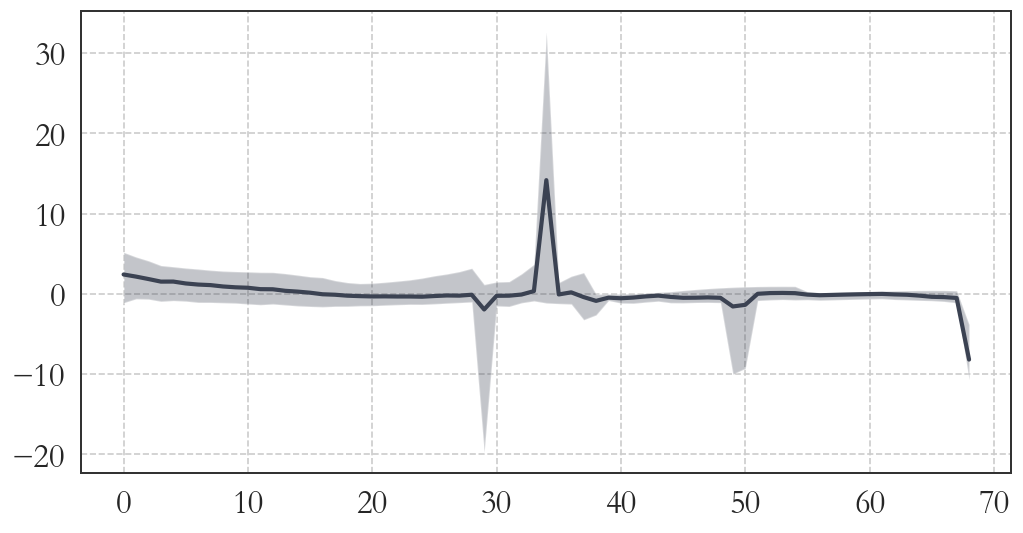

In [47]:
pct_dev = 100 * (sim.c[:, 1:] - sim.c[:, :-1]) / sim.c[:, :-1]

mean_dev = np.mean(pct_dev, axis=0)
se_dev = np.std(pct_dev, axis=0, ddof=1) / np.sqrt(pct_dev.shape[0])

lower = np.percentile(pct_dev, 5, axis=0)
upper = np.percentile(pct_dev, 95, axis=0)
mean_dev = np.mean(pct_dev, axis=0)

plt.plot(mean_dev)
plt.fill_between(np.arange(pct_dev.shape[1]), lower, upper, alpha=0.3)
plt.show()

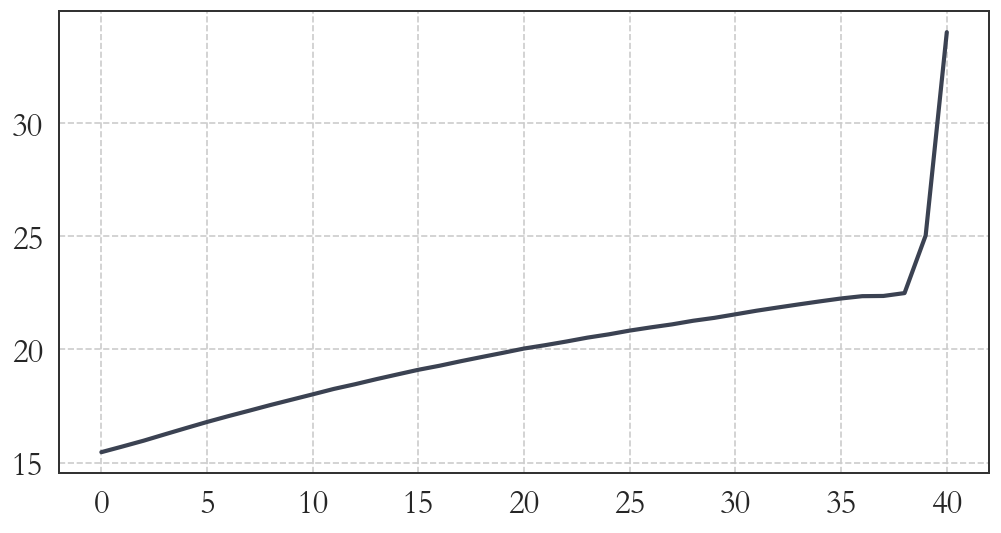

In [23]:
plt.plot(np.nanmean(np.where(model.sim.ex == 1, model.sim.k, np.nan), axis=0))

In [15]:
par.flexible_hours = "NVFI"
par.efter = 1

model.solve()
model.simulate()

In [17]:
model.sim.w

array([[389979.74694546, 388553.08205948, 396310.57837576, ...,
        343621.54990893, 339511.78141607, 335610.85519887],
       [719770.54066199, 709516.4144973 , 695669.38722821, ...,
        299649.32284149, 298611.4863456 , 296683.06070899],
       [812293.72338984, 709516.4144973 , 682655.77320751, ...,
        380361.39319911, 374305.23714507, 368579.42882957],
       ...,
       [263260.92      , 263249.86327355, 263216.69588037, ...,
        253495.38852306, 253495.38852306, 253495.38852306],
       [370427.74714579, 375234.6212956 , 382744.08160531, ...,
        336968.6599134 , 334984.99420023, 331311.93833523],
       [263260.92      , 263249.86327355, 263216.69588037, ...,
        253495.38852306, 253495.38852306, 253495.38852306]])

 ...]

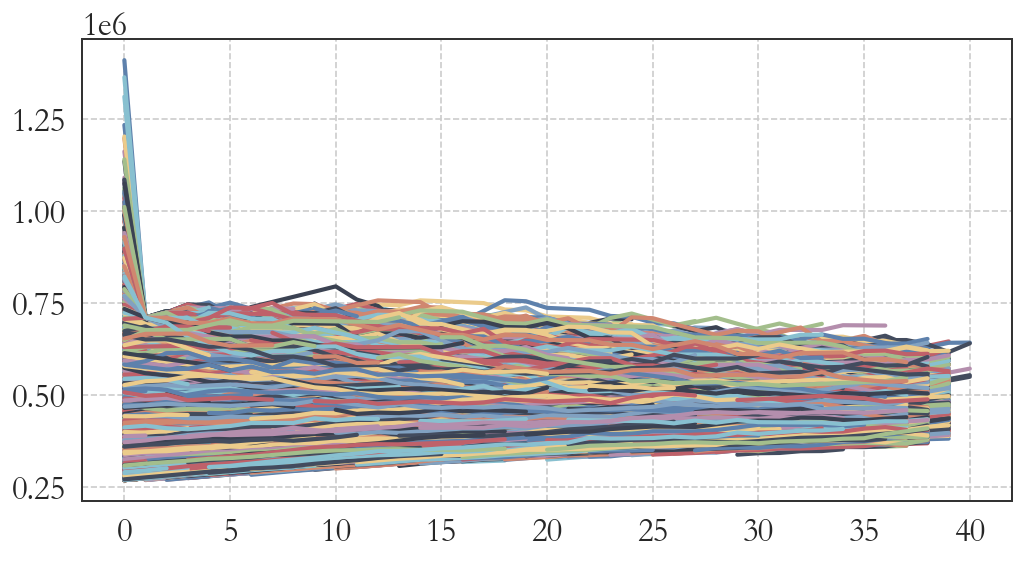

In [18]:
plt.plot(np.where(model.sim.ex.T == 1, model.sim.w.T, np.nan))

In [9]:
np.nanmean(np.where(model.sim.ex == 1, model.sim.w, np.nan), axis=0)

array([399221.5147754 , 400067.30940821, 401866.41552696, 403925.81219394,
       405967.53245146, 407985.99541877, 409847.94582119, 411593.97230972,
       413428.43345184, 415094.17532051, 416790.36127341, 418497.69597356,
       419828.26303901, 421380.66814056, 422743.97047418, 424100.92701488,
       425122.83050596, 426334.58209428, 427455.22044941, 428481.50525931,
       429583.655635  , 430199.03300666, 430924.78696365, 431751.82771139,
       432252.14894316, 432997.00803467, 433440.00845245, 433725.91958668,
       434306.97226415, 434509.45790381, 434990.69051339, 436592.02184592,
       438003.53356117, 439382.59845907, 440737.04753282, 442037.79583839,
       443042.62895719, 442997.42499807, 444440.54740593, 474736.98752616,
       590579.375348  ,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,  

In [1]:
plt.plot(np.nanmean(np.where(model.sim.ex == 1, model.sim.k, np.nan), axis=0))

NameError: name 'plt' is not defined

In [17]:
i = 6

par.k_m_grid[i, :, i, 1]

array([ 0.        ,  0.90171071,  1.8902032 ,  2.98101734,  4.19401059,
        5.55507023,  7.09875265,  8.87251864, 10.9438707 , 13.41313495,
       16.4382094 , 20.28774517, 25.47364969, 33.16727051, 47.23449551])

In [30]:
hours_mean

array([0.84699617, 0.84692365, 0.84718836, 0.84723473, 0.84680186,
       0.84560637, 0.84408199, 0.84159272, 0.84054133, 0.83845081,
       0.83454098, 0.83171763, 0.82952751, 0.829805  , 0.83084057,
       0.83185565, 0.83243485, 0.83285206, 0.83313127, 0.83304747,
       0.83280437, 0.83202293, 0.83073233, 0.82876901, 0.82561213,
       0.8214936 , 0.81614889, 0.80955481, 0.80182653, 0.79332266,
       0.78294283, 0.77952186, 0.77130533, 0.76434836, 0.75709263,
       0.652253  , 0.63736203, 0.62264536, 0.62407816, 0.61782023,
       0.62361862, 0.63295813, 0.63922527, 0.64230857,        nan])

In [7]:
# prepare your data dict
a_dict = {
    'hours': [np.nanmean(np.where(model.sim.ex == 1, model.sim.h, np.nan), axis=0)[:55],
              moments['hours']],
    'extensive': [np.mean(model.sim.ex, axis=0)[:55],
                  moments['extensive']],
    'liquid': [np.mean(model.sim.a, axis=0),
               moments['assets']]
}


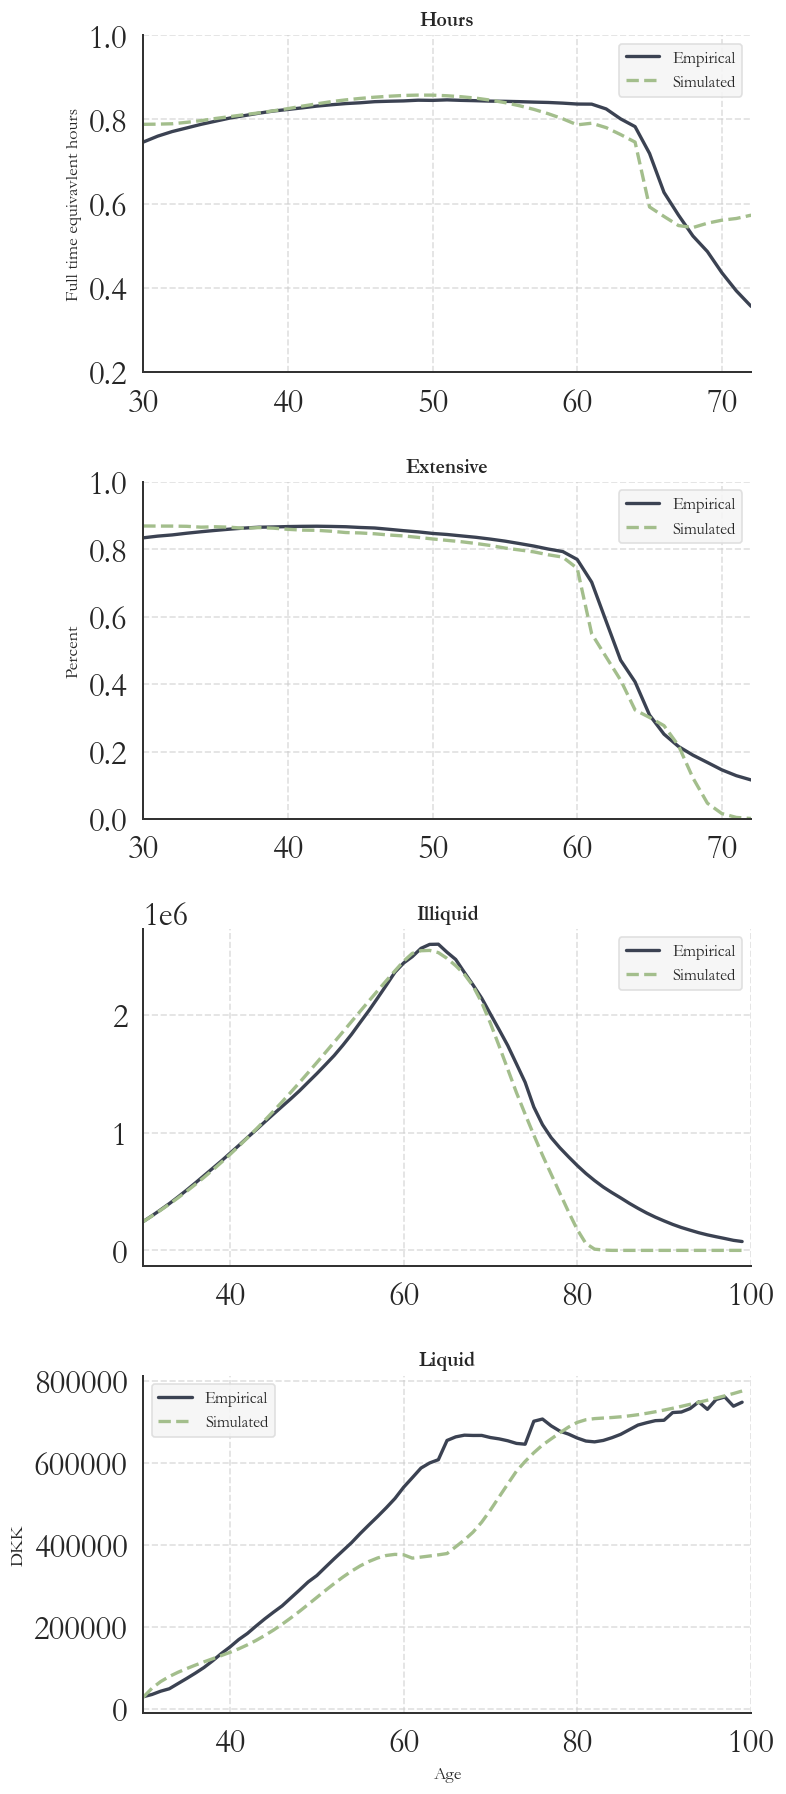

In [10]:
plot_model_vs_data_grid(a_dict, title="", save_title="in_sample_fit.png")


In [9]:
means_data = pd.read_csv("Data/mean_matrix.csv")

b_dict = {
    'illiquid': [np.clip(np.clip(np.mean(model.sim.s, axis=0), 0, None) / 1_000_000, 0, None),
                 moments['savings'] / 1_000_000]  ,
    'wages':    [np.nanmean(np.where(model.sim.ex==1, model.sim.w, np.nan)[:, :31] , axis=0),
                 means_data[means_data["alder"] <= 60]["hourly_salary_plsats_Mean"].to_numpy() * 1924]
        }

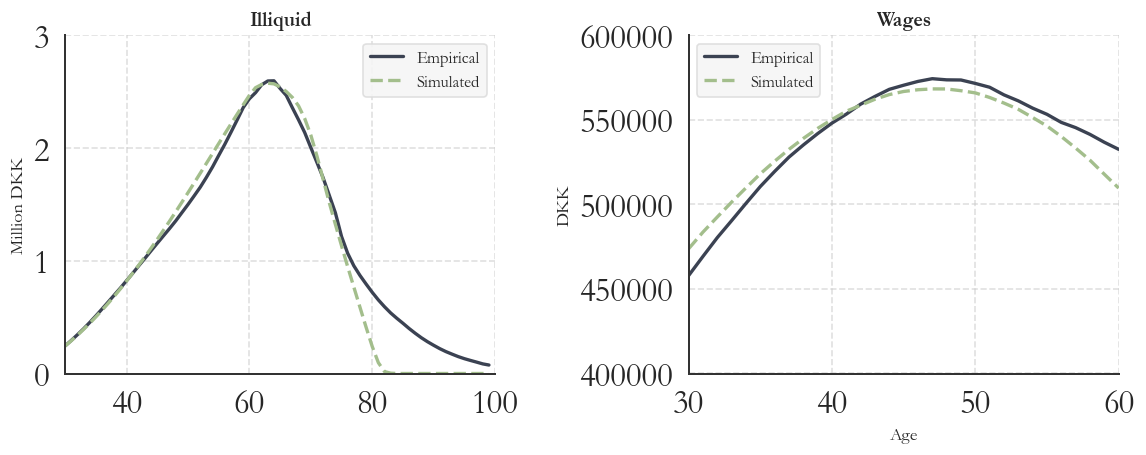

In [10]:
plot_model_vs_data_grid_oos(b_dict, title="", save_title="out_of_sample_fit.png")


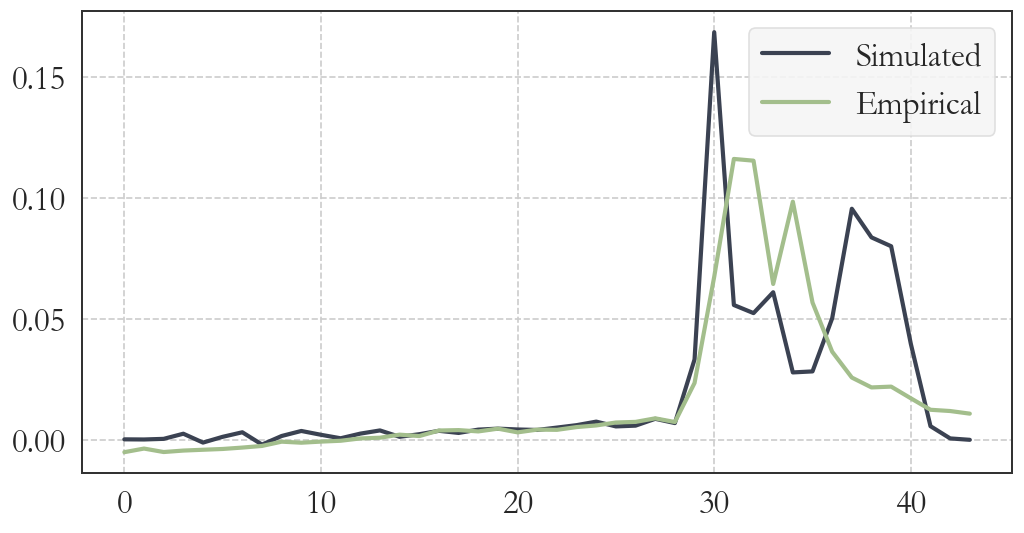

In [12]:
#take first differences of this np.mean(model.sim.ex, axis=0)[:45]

diff_ex_sim = -np.diff(np.mean(model.sim.ex, axis=0)[:45], axis=0)
diff_ex_moments = -np.diff(moments['extensive'][:45], axis=0)
plt.plot(diff_ex_sim, label='Simulated')
plt.plot(diff_ex_moments, label='Empirical')
plt.legend()
plt.show()

(0.0, 250000.0)

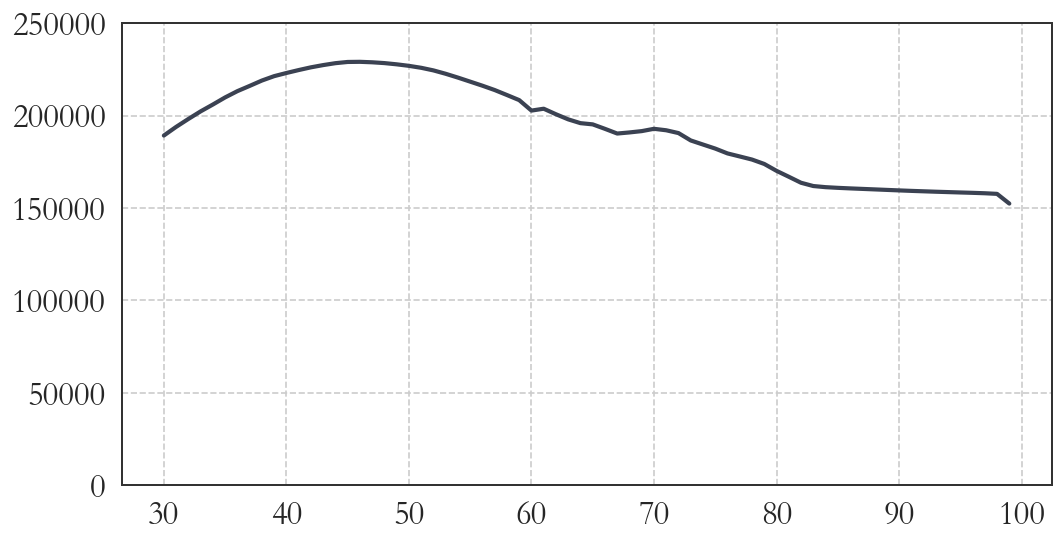

In [13]:
mask = model.sim.a > 0
c_filtered_mean = np.nanmean(np.where(mask, model.sim.c, np.nan), axis=0)

plt.plot(x_vals, c_filtered_mean, label='Simulated Consumption')
plt.ylim(0, 250000)

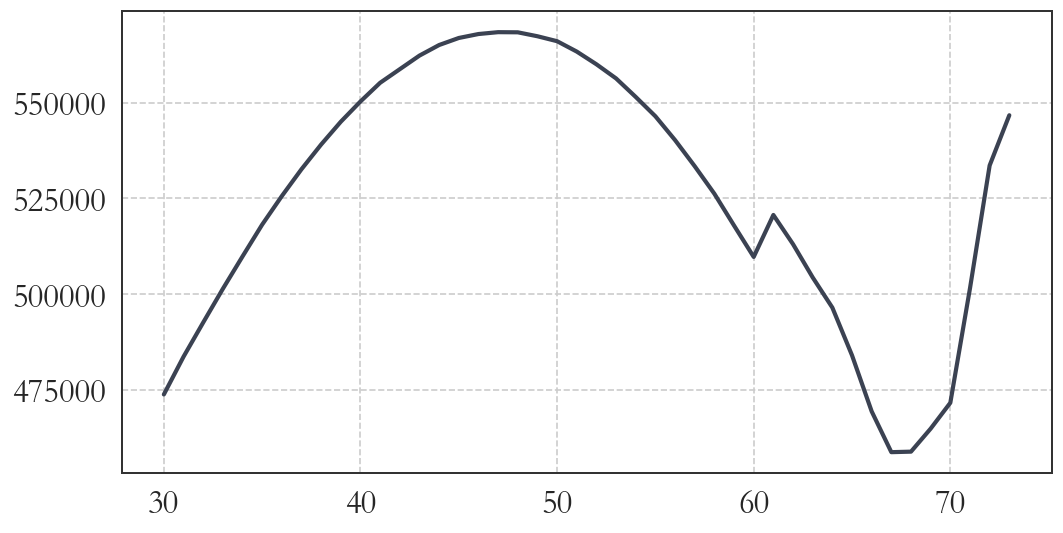

In [14]:
mask = model.sim.ex == 1
c_filtered_mean = np.nanmean(np.where(mask, model.sim.w, np.nan), axis=0)

plt.plot(x_vals, c_filtered_mean, label='Simulated Consumption')
# plt.ylim(0, 250000)

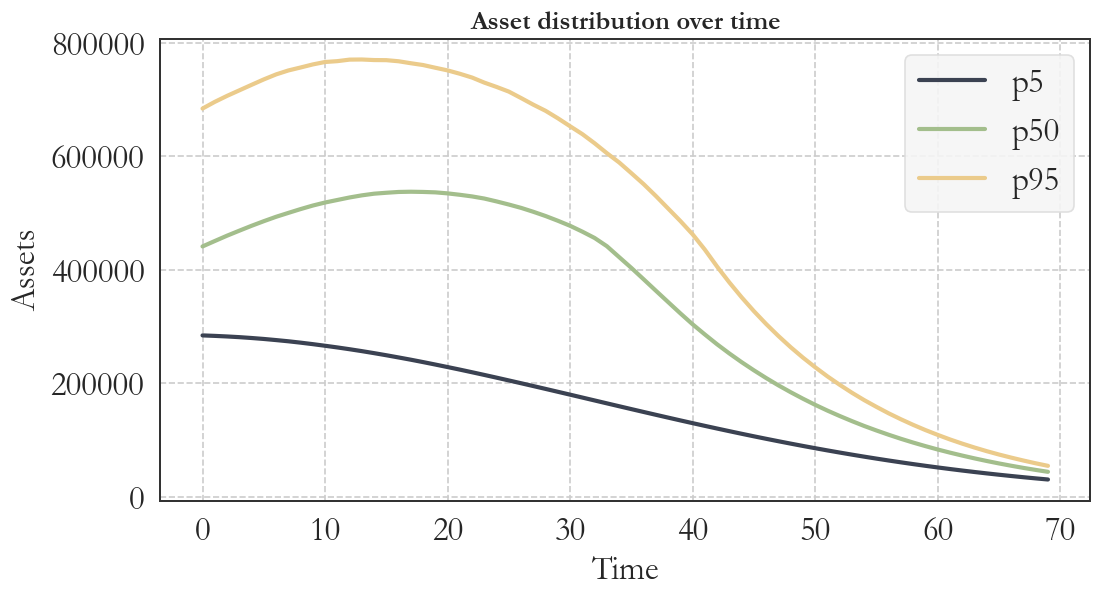

In [15]:
import numpy as np

w = model.sim.w
p5_w = np.percentile(w, 5, axis=0)
p50_w = np.percentile(w, 50, axis=0)
p95_w = np.percentile(w, 95, axis=0)

plt.figure()
plt.plot(p5_w, label='p5')
plt.plot(p50_w, label='p50')
plt.plot(p95_w, label='p95')
plt.xlabel('Time')
plt.ylabel('Assets')
plt.title('Asset distribution over time')
plt.legend()
plt.show()

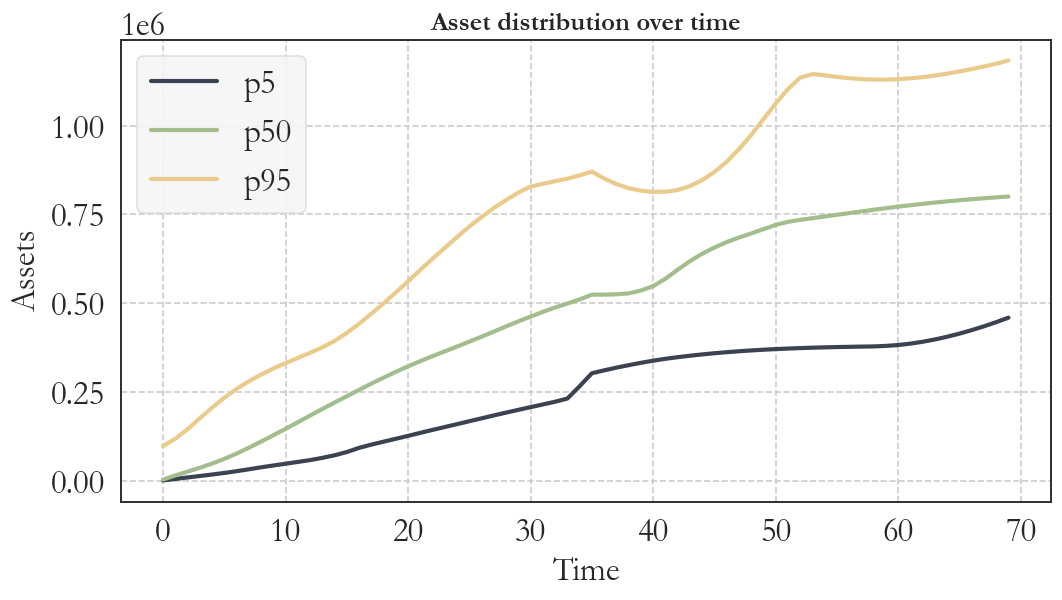

In [16]:
import numpy as np

a = model.sim.a
p5 = np.percentile(a, 5, axis=0)
p50 = np.percentile(a, 50, axis=0)
p95 = np.percentile(a, 95, axis=0)

plt.figure()
plt.plot(p5, label='p5')
plt.plot(p50, label='p50')
plt.plot(p95, label='p95')
plt.xlabel('Time')
plt.ylabel('Assets')
plt.title('Asset distribution over time')
plt.legend()
plt.show()

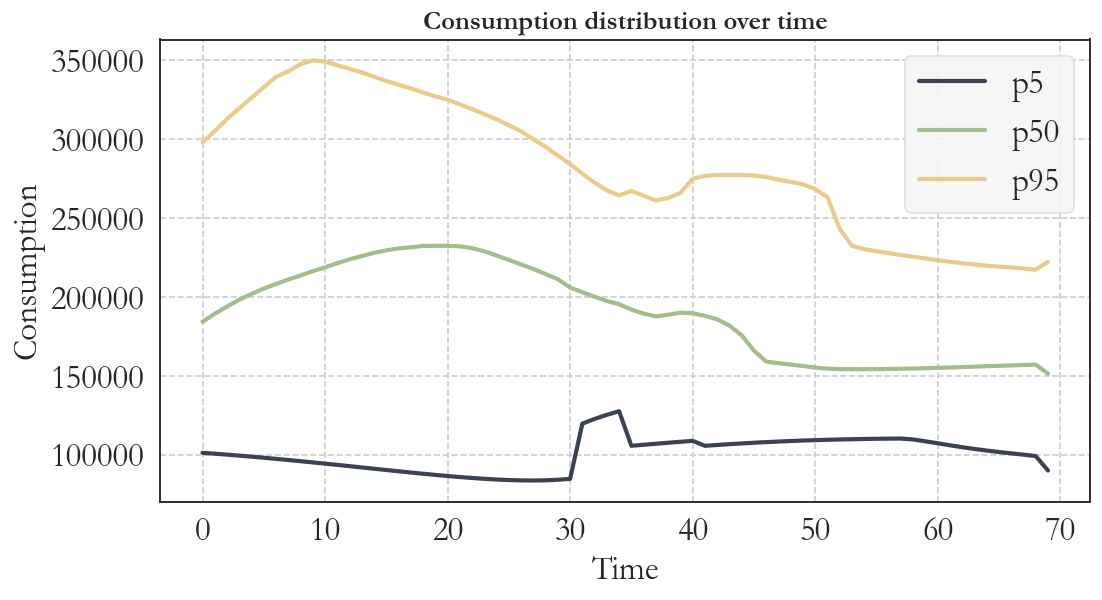

In [17]:
import numpy as np

c = model.sim.c
p5_c  = np.percentile(c, 5, axis=0)
p50_c = np.percentile(c, 50, axis=0)
p95_c = np.percentile(c, 95, axis=0)

plt.figure()
plt.plot(p5_c, label='p5')
plt.plot(p50_c, label='p50')
plt.plot(p95_c, label='p95')
plt.xlabel('Time')
plt.ylabel('Consumption')
plt.title('Consumption distribution over time')
plt.legend()
plt.show()

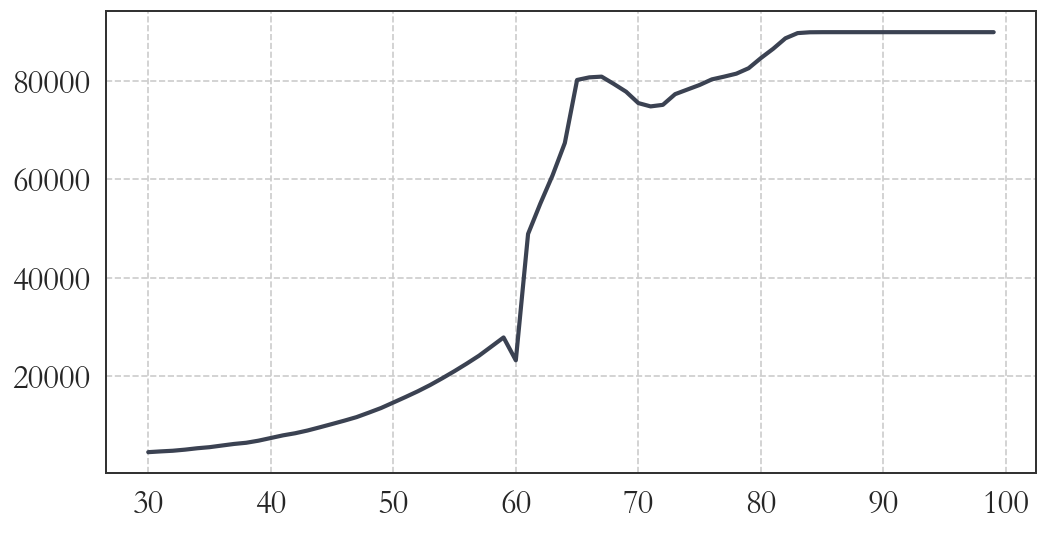

In [18]:
plt.plot(x_vals, model.sim.chi_payment.mean(axis=0), label='Simulated Chi Payment') 

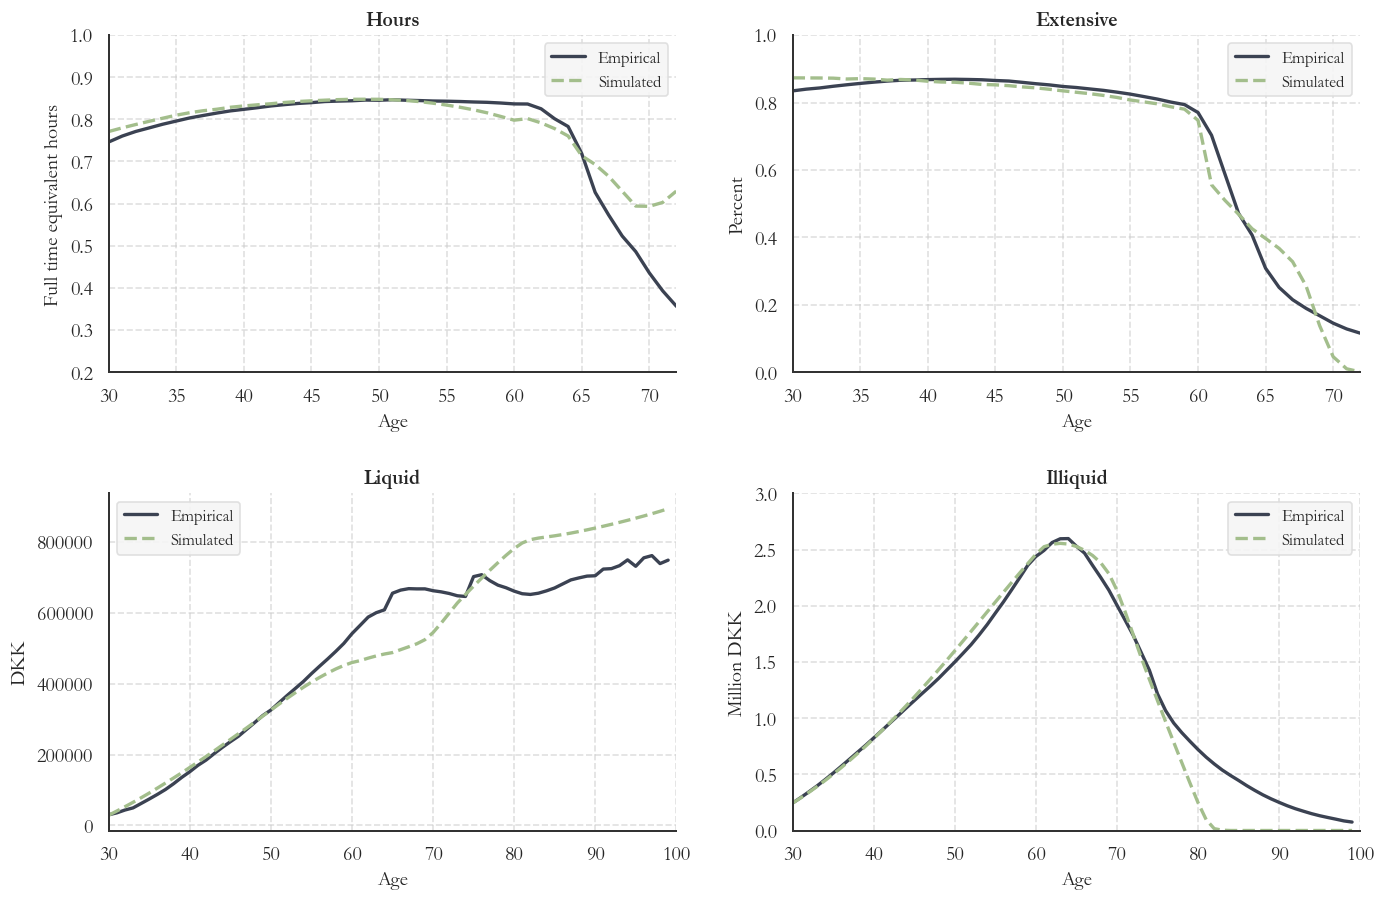

In [11]:
a_dict_new = {
    'hours': [np.nanmean(np.where(model.sim.ex == 1, model.sim.h, np.nan), axis=0)[:43],
            moments['hours']],
    'extensive': [np.mean(model.sim.ex, axis=0)[:43],
                  moments['extensive']],
    'liquid': [np.mean(model.sim.a, axis=0),
            moments['assets']],
    'illiquid': [np.clip(np.clip(np.mean(model.sim.s, axis=0), 0, None) / 1_000_000, 0, None),
            moments['savings'] / 1_000_000]  ,
}


plot_model_vs_data_2x3(a_dict_new, title=None, save_title="2018_all_graph_slides")

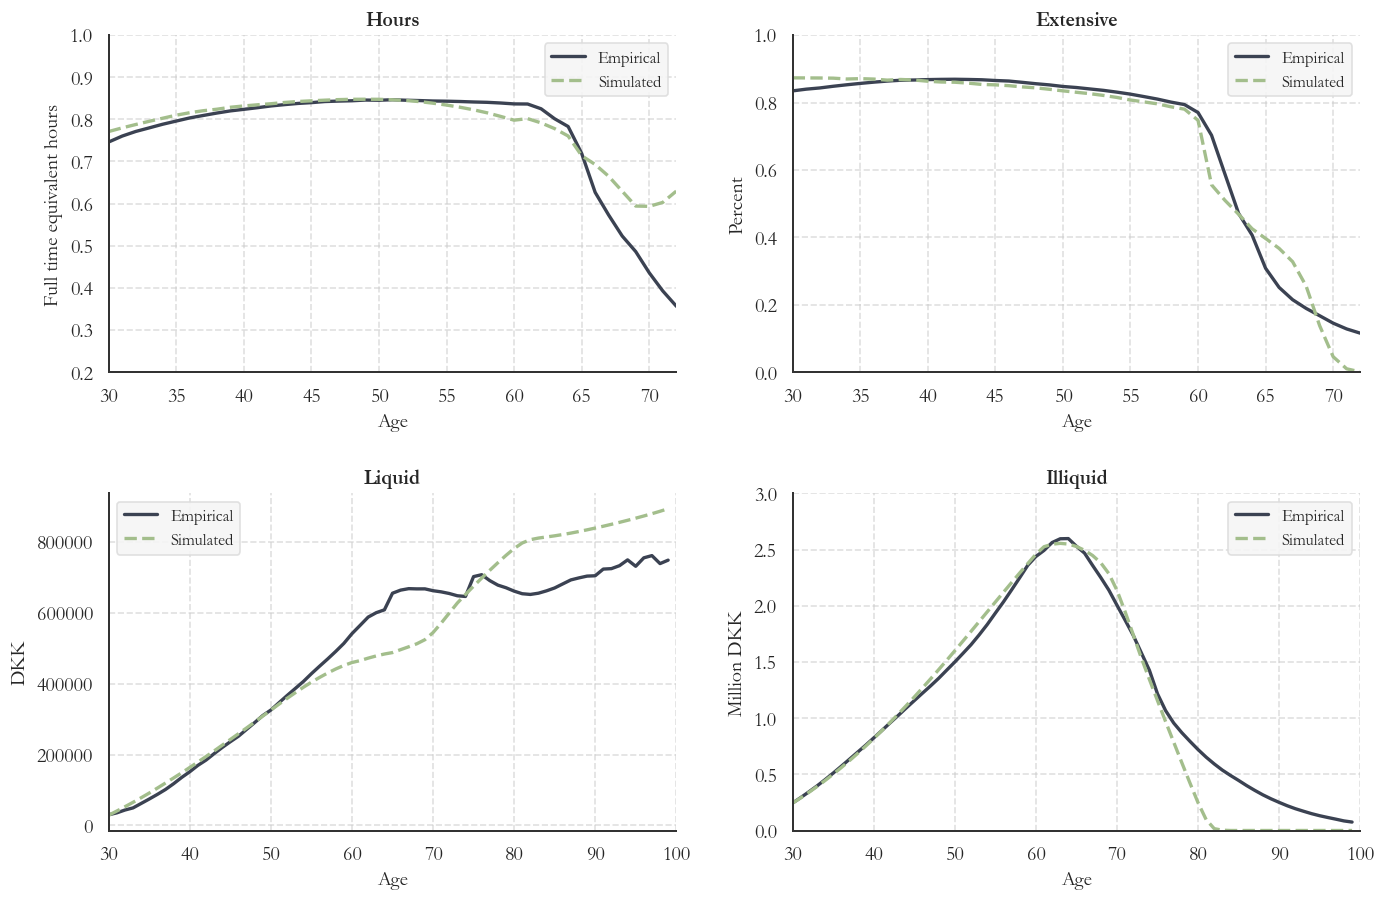

In [12]:
plot_model_vs_data_3x2(a_dict_new, title=None, save_title="oos_all_graph")

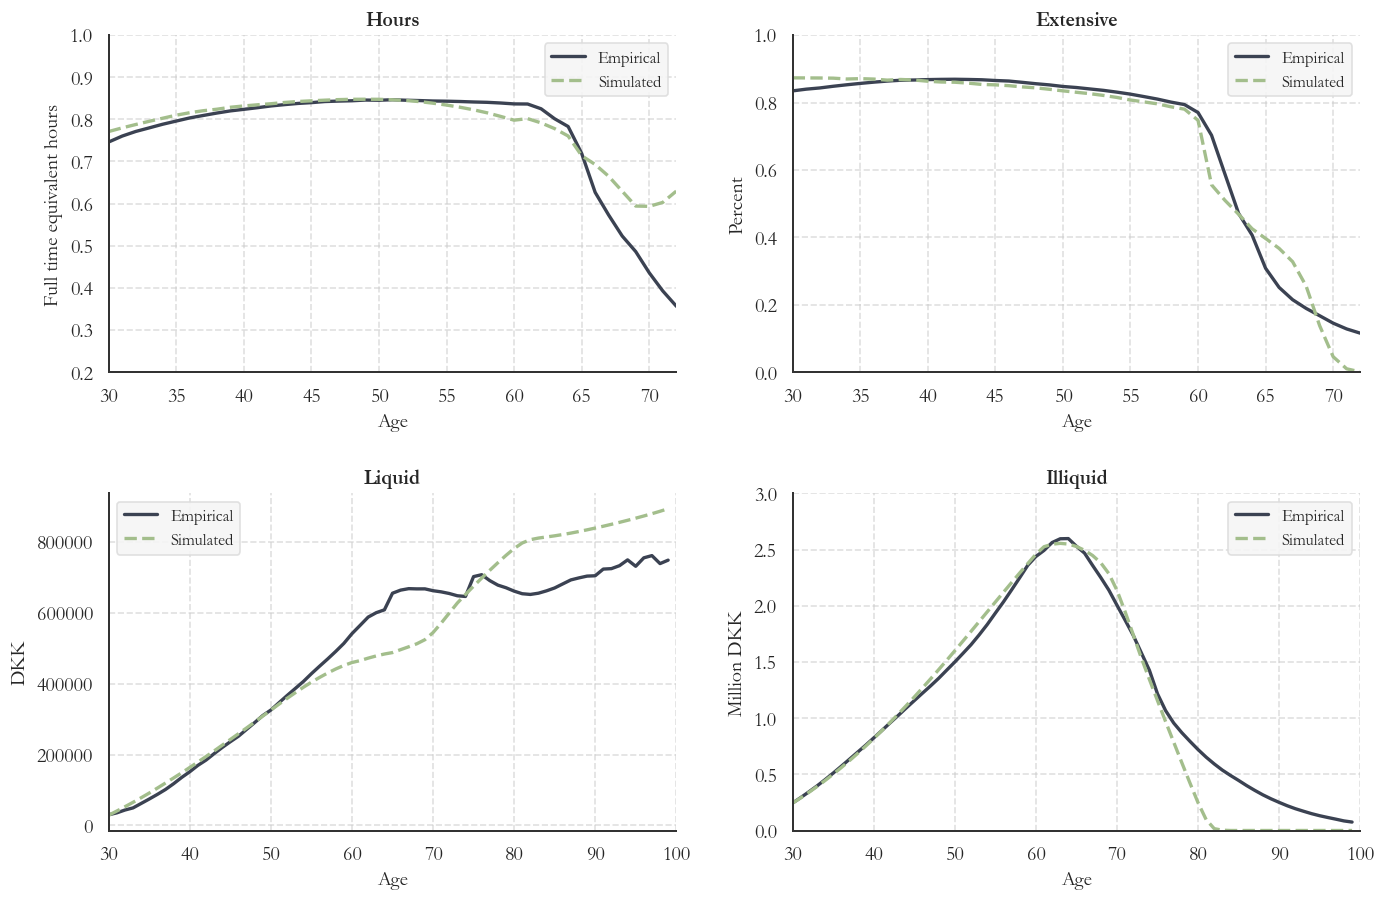

In [13]:


plot_model_vs_data_2x3(a_dict_new, title=None, save_title="oos_all_graph")